# 06 — Evaluation and Results

**Notebook purpose:** Bring together the ARIMA benchmark (`04`), the XGBoost challenger (`05`), and a Ridge linear baseline trained on the identical feature set, then compare them under four complementary lenses:

1. **Head-to-head RMSE/MAE** over the primary `test_window_months`-month holdout.
2. **Diebold-Mariano (1995)** test for equal predictive accuracy.
3. **Clark-West (2007)** MSPE-adjusted test, appropriate here because ARIMA's own lags are *nested* inside both the Ridge and XGBoost feature sets, which is known to undersize the plain DM test.
4. **Moving-block bootstrap** confidence interval on the RMSE improvement, to report an uncertainty band rather than a single point estimate.
5. A **robustness check across alternative holdout window lengths** (36/48/60/84 months), since a single test window can make an improvement look more (or less) stable than it is.

All tables/figures exported here are referenced directly from `reports/draft_note.md`.

---

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_config, get_path
from src.evaluate import rmse, mae, diebold_mariano_test, clark_west_test, moving_block_bootstrap_rmse_ci
from src.models import run_ridge_challenger

config = load_config('../config.yaml')
target_col = config['target']['fred_series']
test_window_months = config['modeling']['test_window_months']

arima_df = pd.read_csv('../data/processed/results_arima.csv', parse_dates=['date'], index_col='date')
xgb_df = pd.read_csv('../data/processed/results_xgb.csv', parse_dates=['date'], index_col='date')
feature_df = pd.read_csv('../data/processed/feature_matrix.csv', parse_dates=['date'], index_col='date')

results = arima_df[['y_true', 'y_pred_arima']].join(xgb_df[['y_pred_xgb']])
results.tail()

,y_true,y_pred_arima,y_pred_xgb
date,,,
2024-08-31,4.2,4.306595,4.056743
2024-09-30,4.1,4.300084,4.234187
2024-10-31,4.1,4.199456,4.142831
2024-11-30,4.2,4.205497,4.138800
2024-12-31,4.1,4.304825,4.123302


## 0. Ridge linear baseline (same feature set as XGBoost)

ARIMA and XGBoost differ along two dimensions at once: XGBoost sees far more predictors (lagged FRED series, Google Trends, rolling stats, seasonal dummies) *and* is a nonlinear tree ensemble. A raw ARIMA-vs-XGBoost comparison can't tell us which of those two changes drives any RMSE improvement.

Ridge regression trained on **the identical feature matrix and expanding-window protocol** as XGBoost isolates the "more predictors" effect from the "nonlinear model" effect: if Ridge already matches XGBoost, the gain is about feature richness, not tree-based nonlinearity; if XGBoost still leads Ridge by a wide margin, nonlinearity/interactions are doing real work.

In [2]:
ridge_result, ridge_model = run_ridge_challenger(
    feature_df,
    target_col=target_col,
    test_window_months=test_window_months,
    alpha=config['modeling']['ridge_alpha'],
    random_state=config['modeling']['random_state'],
)
ridge_df = ridge_result.to_frame('ridge')
ridge_df.to_csv(get_path(config['paths']['processed_dir'] + '/results_ridge.csv'))

results = results.join(ridge_df[['y_pred_ridge']])
results.tail()

,y_true,y_pred_arima,y_pred_xgb,y_pred_ridge
date,,,,
2024-08-31,4.2,4.306595,4.056743,4.077469
2024-09-30,4.1,4.300084,4.234187,4.169132
2024-10-31,4.1,4.199456,4.142831,4.205653
2024-11-30,4.2,4.205497,4.138800,4.174179
2024-12-31,4.1,4.304825,4.123302,4.115065


## 1. Head-to-head accuracy table

In [3]:
metrics_table = pd.DataFrame({
    'RMSE': {
        'ARIMA (benchmark)': rmse(results['y_true'], results['y_pred_arima']),
        'Ridge (linear, same features as XGBoost)': rmse(results['y_true'], results['y_pred_ridge']),
        'XGBoost (challenger)': rmse(results['y_true'], results['y_pred_xgb']),
    },
    'MAE': {
        'ARIMA (benchmark)': mae(results['y_true'], results['y_pred_arima']),
        'Ridge (linear, same features as XGBoost)': mae(results['y_true'], results['y_pred_ridge']),
        'XGBoost (challenger)': mae(results['y_true'], results['y_pred_xgb']),
    },
})
metrics_table['RMSE improvement vs. ARIMA (%)'] = (
    (metrics_table.loc['ARIMA (benchmark)', 'RMSE'] - metrics_table['RMSE'])
    / metrics_table.loc['ARIMA (benchmark)', 'RMSE'] * 100
)
metrics_table

,RMSE,MAE,RMSE improvement vs. ARIMA (%)
ARIMA (benchmark),1.695152,0.547223,0.000000
"Ridge (linear, same features as XGBoost)",3.176440,0.903214,-87.383719
XGBoost (challenger),1.418479,0.470078,16.321455


## 2. Diebold-Mariano test for equal predictive accuracy

$H_0$: the two models have equal expected squared-error loss. A significant negative DM statistic (loss differential = model-1 error$^2$ minus model-2 error$^2$) indicates model 2 significantly outperforms model 1.

In [4]:
e_arima = results['y_true'] - results['y_pred_arima']
e_ridge = results['y_true'] - results['y_pred_ridge']
e_xgb = results['y_true'] - results['y_pred_xgb']

dm_pairs = {
    'ARIMA vs. XGBoost': (e_arima, e_xgb),
    'ARIMA vs. Ridge': (e_arima, e_ridge),
    'Ridge vs. XGBoost': (e_ridge, e_xgb),
}
dm_rows = []
for label, (e1, e2) in dm_pairs.items():
    dm_stat, dm_p = diebold_mariano_test(e1.values, e2.values, h=1)
    dm_rows.append({'comparison': label, 'dm_statistic': dm_stat, 'p_value': dm_p})
    print(f'{label:22s}  DM = {dm_stat:7.4f}   p = {dm_p:.4f}')

dm_table = pd.DataFrame(dm_rows).set_index('comparison')
dm_table

ARIMA vs. XGBoost       DM =  1.0070   p = 0.3139
ARIMA vs. Ridge         DM = -1.5298   p = 0.1261
Ridge vs. XGBoost       DM =  1.5669   p = 0.1171


,dm_statistic,p_value
comparison,,
ARIMA vs. XGBoost,1.007038,0.313916
ARIMA vs. Ridge,-1.529772,0.126073
Ridge vs. XGBoost,1.566948,0.117127


## 3. Clark-West (2007) test for nested models

The DM test above treats ARIMA and XGBoost/Ridge as unrelated models, but ARIMA's own information set (lagged `UNRATE`) is a strict subset of what XGBoost and Ridge see — the larger models *nest* the benchmark. Comparing nested models with plain DM is known to be undersized (Clark & West, 2007): the extra, truly-zero coefficients in the larger model still add estimation noise to its point forecasts, which the DM test penalizes as if it were genuine information disadvantage. The CW statistic corrects for this and is the more appropriate test here.

$H_0$: equal accuracy. $H_1$ (one-sided): the larger (unrestricted) model is more accurate. Reported p-values are one-sided.

In [5]:
cw_pairs = {
    'ARIMA (restricted) vs. XGBoost (unrestricted)': ('y_pred_arima', 'y_pred_xgb'),
    'ARIMA (restricted) vs. Ridge (unrestricted)': ('y_pred_arima', 'y_pred_ridge'),
}
cw_rows = []
for label, (restricted_col, unrestricted_col) in cw_pairs.items():
    cw_stat, cw_p = clark_west_test(
        results['y_true'].values, results[restricted_col].values, results[unrestricted_col].values, h=1
    )
    cw_rows.append({'comparison': label, 'cw_statistic': cw_stat, 'p_value_one_sided': cw_p})
    print(f'{label:50s}  CW = {cw_stat:7.4f}   one-sided p = {cw_p:.4f}')

cw_table = pd.DataFrame(cw_rows).set_index('comparison')
cw_table

ARIMA (restricted) vs. XGBoost (unrestricted)       CW =  1.1709   one-sided p = 0.1208
ARIMA (restricted) vs. Ridge (unrestricted)         CW = -1.4359   one-sided p = 0.9245


,cw_statistic,p_value_one_sided
comparison,,
ARIMA (restricted) vs. XGBoost (unrestricted),1.170864,0.120827
ARIMA (restricted) vs. Ridge (unrestricted),-1.435943,0.924491


## 4. Moving-block bootstrap CI on the RMSE improvement

A single point estimate ("16.3% RMSE improvement") invites over-interpretation. We resample the evaluation window in contiguous blocks (preserving the serial correlation in monthly forecast errors) to construct a confidence interval around the improvement.

In [6]:
bootstrap_cfg = config['modeling']['bootstrap']
bootstrap_rows = []
for label, challenger_col in [('XGBoost vs. ARIMA', 'y_pred_xgb'), ('Ridge vs. ARIMA', 'y_pred_ridge')]:
    ci_result = moving_block_bootstrap_rmse_ci(
        results['y_true'].values,
        results['y_pred_arima'].values,
        results[challenger_col].values,
        block_size=bootstrap_cfg['block_size'],
        n_boot=bootstrap_cfg['n_boot'],
        ci=bootstrap_cfg['ci_level'],
        random_state=config['modeling']['random_state'],
    )
    ci_result['comparison'] = label
    bootstrap_rows.append(ci_result)
    print(
        f"{label:20s}  {ci_result['point_estimate_pct']:6.2f}%  "
        f"[{ci_result['ci_lower_pct']:6.2f}%, {ci_result['ci_upper_pct']:6.2f}%] "
        f"({int(ci_result['ci_level']*100)}% block-bootstrap CI, block={ci_result['block_size']}mo)"
    )

bootstrap_table = pd.DataFrame(bootstrap_rows).set_index('comparison')
bootstrap_table[['point_estimate_pct', 'ci_lower_pct', 'ci_upper_pct', 'boot_se_pct']]

XGBoost vs. ARIMA      16.32%  [-61.85%,  44.86%] (90% block-bootstrap CI, block=6mo)


Ridge vs. ARIMA       -87.38%  [-147.38%,  13.22%] (90% block-bootstrap CI, block=6mo)


,point_estimate_pct,ci_lower_pct,ci_upper_pct,boot_se_pct
comparison,,,,
XGBoost vs. ARIMA,16.321455,-61.849600,44.864206,31.216878
Ridge vs. ARIMA,-87.383719,-147.376565,13.223149,46.606045


## 5. Forecast comparison plot

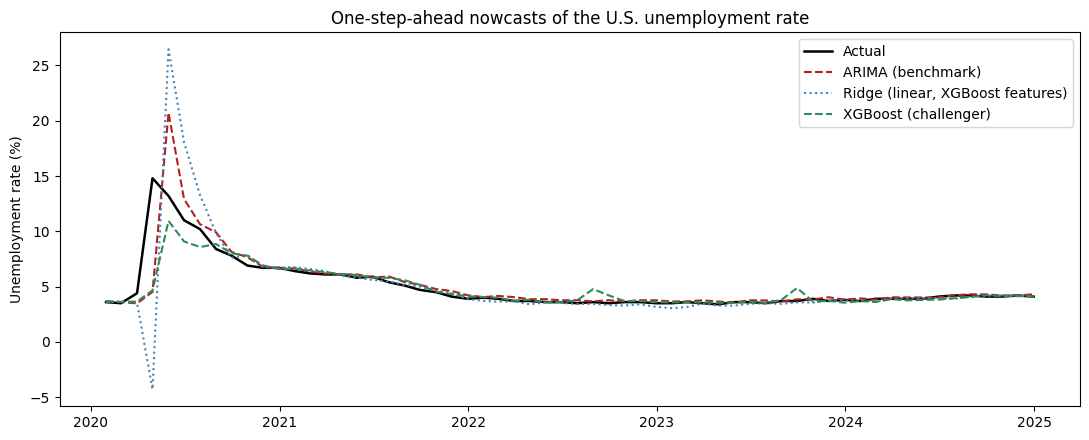

In [7]:
plt.figure(figsize=(11, 4.5))
plt.plot(results.index, results['y_true'], label='Actual', color='black', linewidth=1.8)
plt.plot(results.index, results['y_pred_arima'], label='ARIMA (benchmark)', color='firebrick', linestyle='--')
plt.plot(results.index, results['y_pred_ridge'], label='Ridge (linear, XGBoost features)', color='steelblue', linestyle=':')
plt.plot(results.index, results['y_pred_xgb'], label='XGBoost (challenger)', color='seagreen', linestyle='--')
plt.legend()
plt.title('One-step-ahead nowcasts of the U.S. unemployment rate')
plt.ylabel('Unemployment rate (%)')
plt.tight_layout()
plt.savefig('../reports/fig_forecast_comparison.png', dpi=150)
plt.show()

## 6. Rolling forecast-error comparison

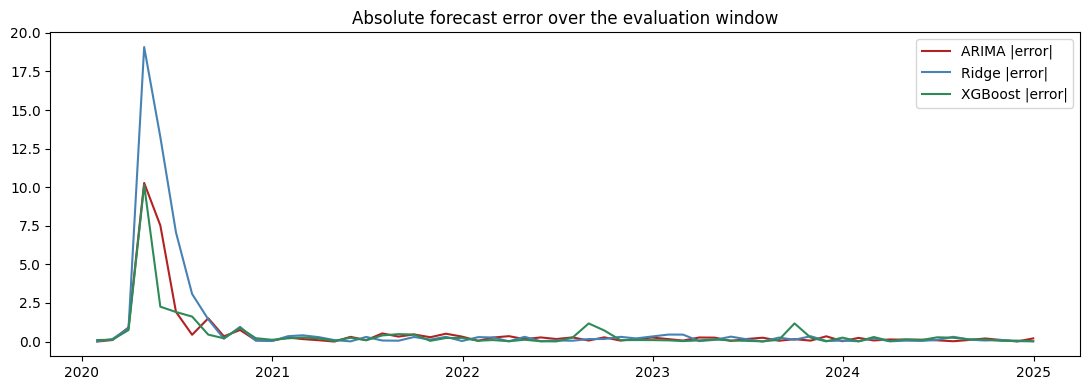

In [8]:
abs_errors = pd.DataFrame({
    'ARIMA |error|': e_arima.abs(),
    'Ridge |error|': e_ridge.abs(),
    'XGBoost |error|': e_xgb.abs(),
}, index=results.index)

plt.figure(figsize=(11, 4))
plt.plot(abs_errors.index, abs_errors['ARIMA |error|'], label='ARIMA |error|', color='firebrick')
plt.plot(abs_errors.index, abs_errors['Ridge |error|'], label='Ridge |error|', color='steelblue')
plt.plot(abs_errors.index, abs_errors['XGBoost |error|'], label='XGBoost |error|', color='seagreen')
plt.legend()
plt.title('Absolute forecast error over the evaluation window')
plt.tight_layout()
plt.savefig('../reports/fig_error_comparison.png', dpi=150)
plt.show()

## 7. Robustness across alternative holdout window lengths

The headline 16.3% RMSE improvement uses a single, fixed 60-month holdout window, which happens to include the 2020 COVID unemployment shock. We re-run the full expanding-window evaluation for `test_window_months` $\in \{36, 48, 60, 84\}$ to check whether the improvement (and its sign) is stable across holdout choices, or an artifact of which macro episodes fall inside the particular window used.

This refits ARIMA, Ridge, and XGBoost from scratch at every step of every window length, so it takes a little longer to run than the rest of the notebook.

In [9]:
from src.models import run_arima_benchmark, run_ml_challenger

panel = pd.read_csv('../data/processed/panel_monthly.csv', parse_dates=['date'], index_col='date')
target_series = panel[target_col]

robustness_rows = []
for window in config['modeling']['robustness_windows']:
    arima_res = run_arima_benchmark(target_series, test_window_months=window, order=tuple(config['modeling']['arima_order']))
    ridge_res, _ = run_ridge_challenger(
        feature_df, target_col=target_col, test_window_months=window,
        alpha=config['modeling']['ridge_alpha'], random_state=config['modeling']['random_state'],
    )
    xgb_res, _ = run_ml_challenger(
        feature_df, target_col=target_col, test_window_months=window,
        xgb_params=config['modeling']['xgboost'], random_state=config['modeling']['random_state'],
    )

    arima_rmse = rmse(arima_res.y_true, arima_res.y_pred)
    ridge_rmse = rmse(ridge_res.y_true, ridge_res.y_pred)
    xgb_rmse = rmse(xgb_res.y_true, xgb_res.y_pred)

    dm_stat, dm_p = diebold_mariano_test(
        np.array(arima_res.y_true) - np.array(arima_res.y_pred),
        np.array(xgb_res.y_true) - np.array(xgb_res.y_pred),
        h=1,
    )

    robustness_rows.append({
        'test_window_months': window,
        'arima_rmse': arima_rmse,
        'ridge_rmse': ridge_rmse,
        'xgb_rmse': xgb_rmse,
        'xgb_improvement_pct': (arima_rmse - xgb_rmse) / arima_rmse * 100,
        'ridge_improvement_pct': (arima_rmse - ridge_rmse) / arima_rmse * 100,
        'dm_statistic': dm_stat,
        'dm_p_value': dm_p,
    })
    print(f"window={window:3d}mo  ARIMA={arima_rmse:.3f}  Ridge={ridge_rmse:.3f}  XGB={xgb_rmse:.3f}  "
          f"XGB improvement={robustness_rows[-1]['xgb_improvement_pct']:+.1f}%  DM p={dm_p:.3f}")

robustness_table = pd.DataFrame(robustness_rows).set_index('test_window_months')
robustness_table

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

...

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\l

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


window= 84mo  ARIMA=1.434  Ridge=2.686  XGB=1.200  XGB improvement=+16.3%  DM p=0.315


,arima_rmse,ridge_rmse,xgb_rmse,xgb_improvement_pct,ridge_improvement_pct,dm_statistic,dm_p_value
test_window_months,,,,,,,
36,0.181845,0.204066,0.328139,-80.449657,-12.219893,-1.376566,0.168646
48,0.224986,0.212683,0.316618,-40.727759,5.468332,-1.194842,0.232149
60,1.695152,3.176440,1.418479,16.321454,-87.383719,1.007038,0.313916
84,1.434087,2.686130,1.200372,16.297132,-87.305987,1.005248,0.314777


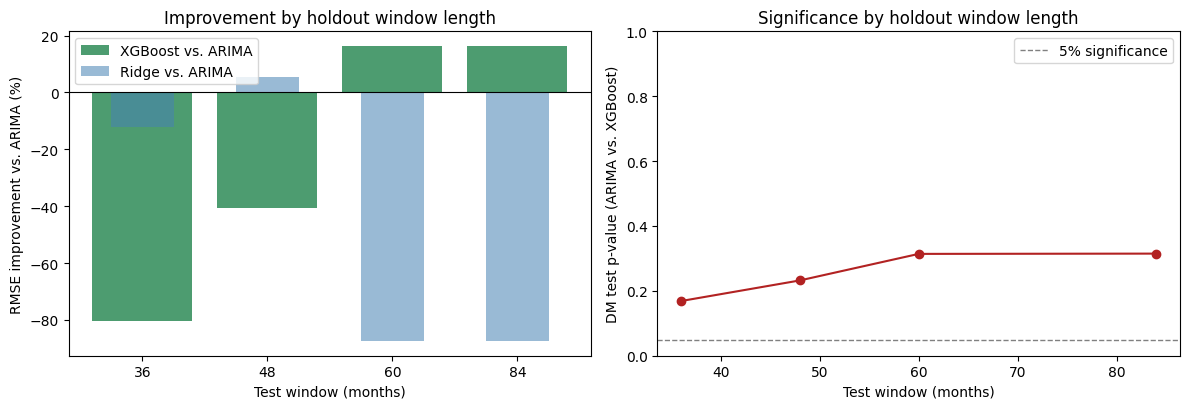

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(
    robustness_table.index.astype(str), robustness_table['xgb_improvement_pct'],
    color='seagreen', alpha=0.85, label='XGBoost vs. ARIMA',
)
axes[0].bar(
    robustness_table.index.astype(str), robustness_table['ridge_improvement_pct'],
    color='steelblue', alpha=0.55, width=0.5, label='Ridge vs. ARIMA',
)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Test window (months)')
axes[0].set_ylabel('RMSE improvement vs. ARIMA (%)')
axes[0].set_title('Improvement by holdout window length')
axes[0].legend()

axes[1].plot(robustness_table.index, robustness_table['dm_p_value'], marker='o', color='firebrick')
axes[1].axhline(0.05, color='gray', linestyle='--', linewidth=1, label='5% significance')
axes[1].set_xlabel('Test window (months)')
axes[1].set_ylabel('DM test p-value (ARIMA vs. XGBoost)')
axes[1].set_title('Significance by holdout window length')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fig_robustness_windows.png', dpi=150)
plt.show()

## 8. Export final results tables for the manuscript

In [11]:
metrics_table.to_csv('../reports/table_main_results.csv')
dm_table.to_csv('../reports/table_dm_test.csv')
cw_table.to_csv('../reports/table_cw_test.csv')
bootstrap_table.to_csv('../reports/table_bootstrap_ci.csv')
robustness_table.to_csv('../reports/table_robustness_windows.csv')
print('Saved: table_main_results.csv, table_dm_test.csv, table_cw_test.csv,')
print('       table_bootstrap_ci.csv, table_robustness_windows.csv')

Saved: table_main_results.csv, table_dm_test.csv, table_cw_test.csv,
       table_bootstrap_ci.csv, table_robustness_windows.csv


---
## Notebook summary

- Added a Ridge linear baseline on the identical feature set as XGBoost, to separate the "more predictors" effect from the "nonlinear model" effect.
- Ran the Diebold-Mariano test (all three pairwise comparisons) and the Clark-West test (appropriate for the nested ARIMA-vs-ML comparisons).
- Reported a moving-block bootstrap confidence interval on the RMSE improvement, not just a point estimate.
- Checked robustness of the headline result across four alternative holdout window lengths (36/48/60/84 months).
- Exported all figures and result tables referenced in `reports/draft_note.md` (Section: Results).

**This completes the empirical pipeline.** See `reports/draft_note.md` for the manuscript draft.